In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, calinski_harabasz_score, davies_bouldin_score, silhouette_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from collections import Counter
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12

In [49]:
fichier_csv = '/content/df_final.csv'

# Charger le CSV
df_final = pd.read_csv(fichier_csv)

# Afficher toutes les colonnes sur une seule ligne
print("Toutes les colonnes :")
print(list(df_final.columns))


Toutes les colonnes :
['intitule_poste', 'nom_entreprise', 'date_publication', 'type_contrat', 'niveau_seniorite', 'description_poste', 'source_offre', 'teletravail', 'metier_recherche', 'id_offre', 'min_experience', 'max_experience', 'departement', 'ville', 'min_salaire', 'max_salaire', 'python', 'c++', 'c', 'r', 'linux', 'ai', 'java', 'angular', 'vue', 'kubernetes', 'agile', 'scrum', 'jira', 'ci/cd', 'javascript', 'css', 'tailwind', 'laravel', 'go', 'git', 'docker', 'php', 'bootstrap', 'react', 'symfony', 'sql', 'mysql', 'postgresql', 'mongodb', 'elasticsearch', 'gitlab', 'graphql', 'microservices', 'ios', 'c#', 'azure', 'power bi', 'scala', 'kanban', 'tdd', 'bdd', 'typescript', 'ruby', 'ruby on rails', 'kotlin', 'spring', 'redis', 'jenkins', 'android', 'oracle', 'sql server', 'windows', 'node.js', 'rust', 'express', 'tableau', 'html', 'nestjs', 'firebase', 'gcp', 'rest api', 'github actions', 'iot', 'kafka', 'asp.net', 'aws', 'soap', 'ansible', 'vscode', 'kibana', 'confluence', 'dar

# Random Forest

## Fonction principale d'analyse des compétences

In [ ]:
def random_forest(df, target_column='metier_recherche', top_n=15):

    # 1. Identification des colonnes
    colonnes_metadonnees = [
        'intitule_poste', 'nom_entreprise', 'date_publication', 'type_contrat',
        'niveau_seniorite', 'description_poste', 'source_offre', 'teletravail',
        'metier_recherche', 'id_offre', 'min_experience', 'max_experience',
        'departement', 'ville', 'min_salaire', 'max_salaire'
    ]

    colonnes_competences = [col for col in df.columns if col not in colonnes_metadonnees]

    # 2. Préparation des données
    X = df[colonnes_competences]
    y = df[target_column]

    mask = y.notna()
    X = X[mask]
    y = y[mask]

    print(f"Données initiales: {X.shape[0]} observations, {X.shape[1]} compétences")

    # Stratégie 1: Filtrage des compétences
    skill_frequency = X.mean()

    # Garder les compétences avec au moins 3% d'occurrence ET au maximum 80%
    relevant_skills = skill_frequency[(skill_frequency > 0.03) & (skill_frequency < 0.8)].index
    X = X[relevant_skills]

    print(f" Après filtrage: {X.shape[1]} compétences pertinentes")

    # Encodage
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Analyse du déséquilibre des classes
    class_dist = pd.Series(y_encoded).value_counts()
    print(f" {len(class_dist)} classes, ratio min/max: {class_dist.min()/class_dist.max():.2f}")

    # 3. Multiple splits
    accuracies = []
    feature_importances = []
    models = []

    # plusieurs random states pour la stabilité
    for random_state in [42, 123, 456]:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded,
            test_size=0.2,
            random_state=random_state,
            stratify=y_encoded
        )

        # Modèle avec paramètres agressifs
        rf_model = RandomForestClassifier(
            n_estimators=500,
            max_depth=25,
            min_samples_split=8,
            min_samples_leaf=3,
            max_features='sqrt',
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced_subsample'
        )

        rf_model.fit(X_train, y_train)

        # Évaluation
        y_pred = rf_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append(accuracy)
        feature_importances.append(rf_model.feature_importances_)
        models.append(rf_model)

        print(f"   Random state {random_state}: Accuracy = {accuracy:.3f}")

    # Prendre le meilleur modèle
    best_idx = np.argmax(accuracies)
    best_model = models[best_idx]
    best_accuracy = accuracies[best_idx]

    # Importance moyenne sur les 3 runs
    avg_importance = np.mean(feature_importances, axis=0)

    # Feature selection basée sur l'importance
    selector = SelectFromModel(best_model, prefit=True, threshold='median')
    X_reduced = selector.transform(X)
    selected_features = X.columns[selector.get_support()]

    print(f"\n Après sélection de features: {X_reduced.shape[1]} compétences retenues")

    # Ré-entraînement avec les features sélectionnées
    X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
        X_reduced, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    rf_final = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )

    rf_final.fit(X_train_red, y_train_red)
    final_accuracy = accuracy_score(y_test_red, rf_final.predict(X_test_red))

    print(f"Accuracy après sélection de features: {final_accuracy:.3f}")

    # 5. Utiliser les importances du meilleur modèle initial
    importance_df = pd.DataFrame({
        'competence': X.columns,
        'importance': avg_importance
    }).sort_values('importance', ascending=False)

    top_competences = importance_df.head(top_n)

    print(f"\n TOP {top_n} COMPÉTENCES LES PLUS IMPORTANTES:")
    print("=" * 50)

    for i, (idx, row) in enumerate(top_competences.iterrows(), 1):
        print(f"{i:2d}. {row['competence']:25} : {row['importance']:.4f}")

    #Validation croisée
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(best_model, X, y_encoded, cv=skf, scoring='accuracy')

    print(f"\n VALIDATION CROISÉE (5 folds):")
    print(f"   Moyenne: {cv_scores.mean():.3f}")
    print(f"   Écart-type: {cv_scores.std():.3f}")
    print(f"   Min: {cv_scores.min():.3f}, Max: {cv_scores.max():.3f}")

    # Visualisation
    fig = visualiser_importances_avance(top_competences.head(10), final_accuracy)

    # Analyse des métriques par classe
    y_pred_full = best_model.predict(X_test)
    print(f"\n RAPPORT DE CLASSIFICATION (meilleur modèle):")
    print(classification_report(y_test, y_pred_full, target_names=le.classes_[:10]))

    return {
        'modele_final': rf_final,
        'modele_initial': best_model,
        'importance_df': importance_df,
        'top_competences': top_competences,
        'accuracy_finale': final_accuracy,
        'accuracy_initial': best_accuracy,
        'cv_scores': cv_scores,
        'encodeur': le,
        'figure': fig,
        'features_selectionnes': selected_features
    }

## Visualisation des résultats

In [ ]:
def visualiser_importances(top_10_competences, accuracy):

    top_10 = top_10_competences.sort_values('importance', ascending=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # Graphique principal
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_10)))
    bars = ax1.barh(top_10['competence'], top_10['importance'],
                    color=colors, alpha=0.85, height=0.7)

    ax1.set_xlabel('Score d\'Importance', fontsize=12, fontweight='bold')
    ax1.set_title(f'Top 10 Compétences - Accuracy: {accuracy:.3f}',
                  fontsize=14, fontweight='bold', pad=20)

    # Ajouter les valeurs
    for i, (bar, importance) in enumerate(zip(bars, top_10['importance'])):
        width = bar.get_width()
        ax1.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{importance:.4f}', ha='left', va='center', fontweight='bold')

    # Graphique secondaire: distribution des importances
    importances = top_10_competences['importance']
    ax2.pie(importances, labels=top_10_competences['competence'],
            autopct='%1.1f%%', startangle=90)
    ax2.set_title('Répartition des Importances', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return fig

## Stratégie en cas d'une accuracy faible

In [ ]:
def strategie_si_basse_accuracy(df, target_column='metier_recherche'):

    print("LANCEMENT DE LA STRATÉGIE AVANCÉE")
    print("=" * 70)

    # 1. Préparation des données
    colonnes_metadonnees = [
        'intitule_poste', 'nom_entreprise', 'date_publication', 'type_contrat',
        'niveau_seniorite', 'description_poste', 'source_offre', 'teletravail',
        'metier_recherche', 'id_offre', 'min_experience', 'max_experience',
        'departement', 'ville', 'min_salaire', 'max_salaire'
    ]

    colonnes_competences = [col for col in df.columns if col not in colonnes_metadonnees]
    X = df[colonnes_competences]
    y = df[target_column]

    mask = y.notna()
    X = X[mask]
    y = y[mask]

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Regrouper les classes trop petites
    class_counts = pd.Series(y).value_counts()
    classes_a_regrouper = class_counts[class_counts < 10].index
    y_modified = y.copy()
    y_modified[y_modified.isin(classes_a_regrouper)] = 'Autre'

    if len(classes_a_regrouper) > 0:
        print(f" Regroupement de {len(classes_a_regrouper)} classes rares en 'Autre'")
        y_encoded = le.fit_transform(y_modified)

    # Essayer différents algorithmes
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from xgboost import XGBClassifier

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    modeles = {
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
        'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
        'SVM': SVC(random_state=42, probability=True),
        'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
    }

    results = {}
    print("COMPARAISON DES ALGORITHMES:")
    print("-" * 40)

    for nom, modele in modeles.items():
        modele.fit(X_train, y_train)
        accuracy = accuracy_score(y_test, modele.predict(X_test))
        results[nom] = accuracy
        print(f"   {nom:20} : {accuracy:.3f}")

    # Prendre le meilleur algorithme
    meilleur_algo = max(results, key=results.get)
    print(f"\n Meilleur algorithme: {meilleur_algo} (Accuracy: {results[meilleur_algo]:.3f})")

    return results, modeles[meilleur_algo]

## Execution

Données initiales: 3877 observations, 125 compétences
 Après filtrage: 50 compétences pertinentes
 8 classes, ratio min/max: 0.02
   Random state 42: Accuracy = 0.521
   Random state 123: Accuracy = 0.490
   Random state 456: Accuracy = 0.497

 Après sélection de features: 25 compétences retenues
Accuracy après sélection de features: 0.486

 TOP 15 COMPÉTENCES LES PLUS IMPORTANTES:
 1. windows                   : 0.0657
 2. git                       : 0.0548
 3. java                      : 0.0500
 4. azure                     : 0.0402
 5. c++                       : 0.0397
 6. go                        : 0.0382
 7. linux                     : 0.0376
 8. sql                       : 0.0374
 9. power bi                  : 0.0363
10. agile                     : 0.0317
11. python                    : 0.0300
12. tableau                   : 0.0293
13. ci/cd                     : 0.0280
14. firewall                  : 0.0265
15. aws                       : 0.0257

 VALIDATION CROISÉE (5 folds)

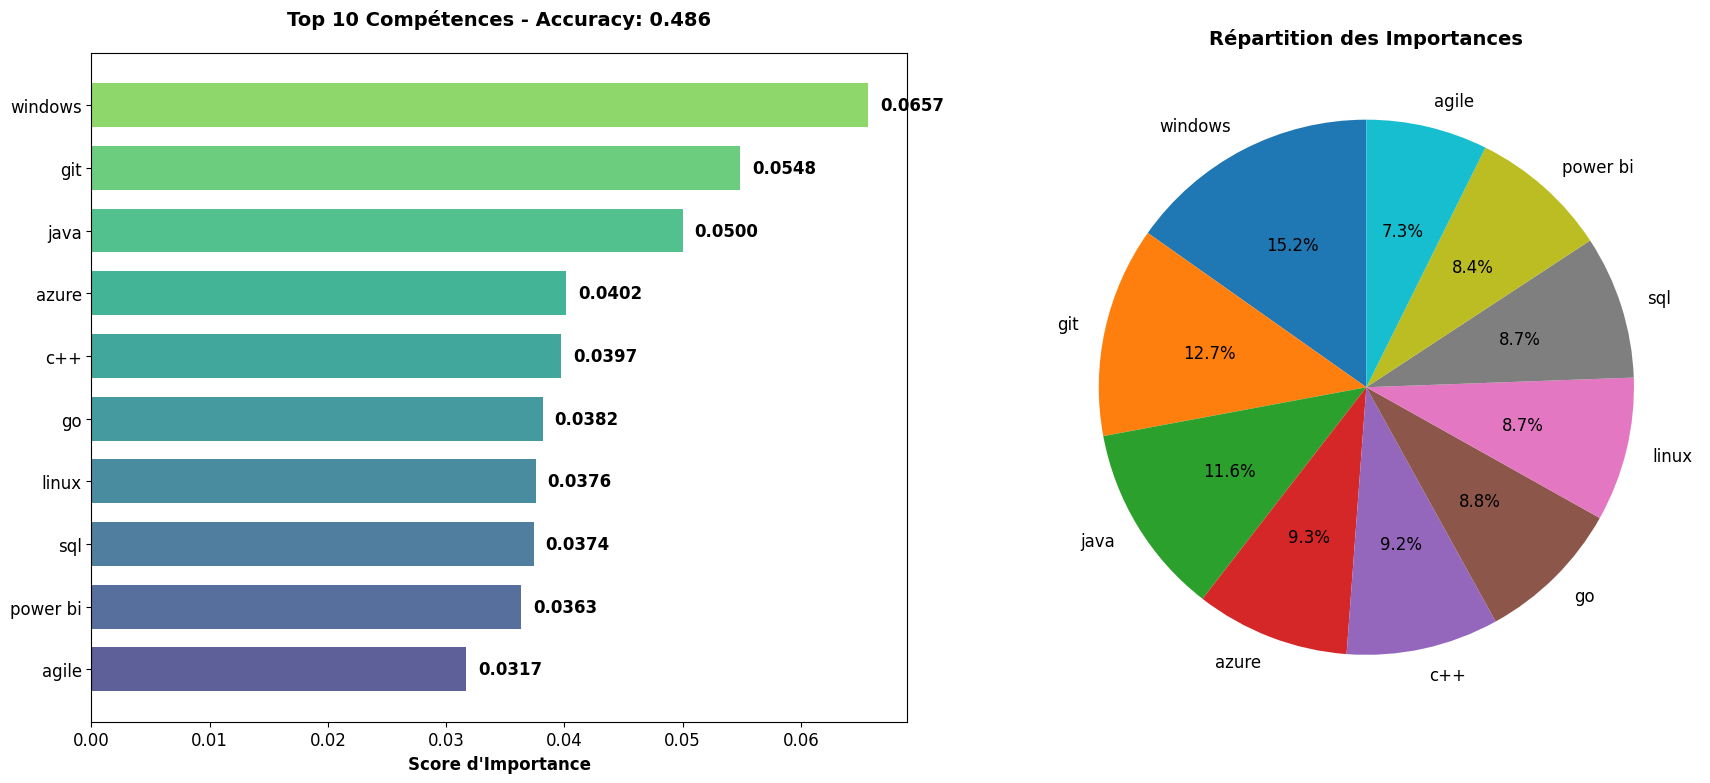


 RAPPORT DE CLASSIFICATION (meilleur modèle):
                           precision    recall  f1-score   support

           Cloud & DevOps       0.71      0.51      0.59       150
            Cybersécurité       0.33      0.68      0.44        91
                     Data       0.70      0.58      0.63       136
                   Design       0.09      0.67      0.16         6
            Développement       0.87      0.62      0.72       243
 Infrastructure & Support       0.46      0.68      0.55        60
               Ingénierie       0.30      0.17      0.22        60
Intelligence Artificielle       0.43      0.33      0.38        30

                 accuracy                           0.56       776
                macro avg       0.49      0.53      0.46       776
             weighted avg       0.65      0.56      0.58       776



In [ ]:
resultats = random_forest(df_final)

# Si l'accuracy reste basse, essayez aussi :
#comparaison, meilleur_modele = strategie_avancee_si_basse_accuracy(df_final)

## Clustering

## Fonction de clustering

In [ ]:
def clustering(df, n_clusters=6, visualisation=True):

    # 1. Identification des colonnes de compétences
    skills_columns = [col for col in df.columns if col not in [
        'intitule_poste', 'nom_entreprise', 'date_publication', 'type_contrat',
        'niveau_seniorite', 'description_poste', 'source_offre', 'teletravail',
        'metier_recherche', 'id_offre', 'min_experience', 'max_experience',
        'departement', 'ville', 'min_salaire', 'max_salaire', 'cluster'
    ]]

    print(f" Compétences identifiées: {len(skills_columns)}")

    # 2. Nettoyage complet des données
    X_clean = df[skills_columns].copy()

    # Remplacer les NaN par 0
    nan_before = X_clean.isna().sum().sum()
    X_clean = X_clean.fillna(0)
    nan_after = X_clean.isna().sum().sum()

    print(f" Nettoyage des NaN: {nan_before} → {nan_after}")

    # Convertir toutes les colonnes en numérique
    for col in X_clean.columns:
        X_clean[col] = pd.to_numeric(X_clean[col], errors='coerce')

    # Remplacer à nouveau les NaN créés par la conversion
    X_clean = X_clean.fillna(0)

    # Filtrer les compétences trop rares ou trop communes
    skill_freq = X_clean.mean()
    skills_to_keep = skill_freq[(skill_freq > 0.02) & (skill_freq < 0.8)].index
    X_filtered = X_clean[skills_to_keep]

    print(f" Compétences après filtrage: {X_filtered.shape[1]}")

    # Vérifier s'il reste assez de données
    if X_filtered.shape[0] < 10 or X_filtered.shape[1] < 3:
        print(" Pas assez de données après nettoyage")
        df_result = df.copy()
        df_result['cluster'] = 0  # Assigner un cluster unique
        return df_result, None, None

    # 3. Standardisation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filtered)

    # Vérifier et corriger les NaN/Inf
    X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    # 4. Clustering K-Means
    print(f"\n APPLICATION DU CLUSTERING K-MEANS ({n_clusters} clusters)...")

    try:
        kmeans = KMeans(
            n_clusters=min(n_clusters, X_scaled.shape[0] // 2),
            random_state=42,
            n_init=10,
            max_iter=200
        )
        clusters = kmeans.fit_predict(X_scaled)
        print(" Clustering réussi")
    except Exception as e:
        print(f" Erreur de clustering: {e}")
        print(" Utilisation de clusters aléatoires comme fallback")
        clusters = np.random.randint(0, n_clusters, len(X_scaled))
        kmeans = None

    # 5. Assignation des résultats
    df_result = df.copy()
    clusters_series = pd.Series(clusters, index=X_filtered.index)
    df_result['cluster'] = clusters_series

    # Pour les lignes manquantes, assigner -1
    df_result['cluster'] = df_result['cluster'].fillna(-1).astype(int)

    # 6. Analyse simple des résultats
    print(f"\n RÉSULTATS DU CLUSTERING:")
    cluster_counts = df_result['cluster'].value_counts().sort_index()
    for cluster_id, count in cluster_counts.items():
        if cluster_id == -1:
            print(f"   Non clusterisé: {count} offres")
        else:
            print(f"   Cluster {cluster_id}: {count} offres")

    # 7. Caractérisation des clusters
    print(f"\n  CARACTÉRISATION DES CLUSTERS:")
    cluster_profiles = {}
    for cluster_id in range(n_clusters):
        cluster_data = df_result[df_result['cluster'] == cluster_id]
        if len(cluster_data) > 0:
            # Top compétences du cluster
            cluster_skills = cluster_data[skills_to_keep].mean().sort_values(ascending=False)
            top_3_skills = cluster_skills.head(3)
            skills_str = ", ".join([f"{skill}" for skill, freq in top_3_skills.items()])
            print(f"   Cluster {cluster_id}: {skills_str}")
            cluster_profiles[cluster_id] = {
                'top_skills': top_3_skills,
                'size': len(cluster_data),
                'skills_str': skills_str
            }

    # 8. Visualisations
    if visualisation:
        print(f"\n GÉNÉRATION DES VISUALISATIONS")
        try:
            visualisations = generer_visualisations(
                df_result, X_scaled, clusters, skills_to_keep, cluster_profiles
            )
            print(" Visualisations générées avec succès")
        except Exception as e:
            print(f" Erreur lors de la génération des visualisations: {e}")
            visualisations = None
    else:
        visualisations = None

    return df_result, kmeans, visualisations

## Fonctions de visualisation

In [ ]:
def generer_visualisations(df, X_scaled, clusters, skills_columns, cluster_profiles):

    visualisations = {}

    # 1. Distribution des clusters
    visualisations['distribution'] = visualiser_distribution_clusters(df)

    # 2. Analyse PCA des clusters
    visualisations['pca'] = visualiser_pca_clusters(X_scaled, clusters, df)

    # 3. Heatmap des compétences par cluster
    visualisations['heatmap'] = generer_heatmap_clusters(df, skills_columns)

    # 4. Radar chart des profils de clusters
    visualisations['radar'] = generer_radar_chart(cluster_profiles, skills_columns)

    # 5. Analyse des métiers par cluster
    if 'metier_recherche' in df.columns:
        visualisations['metiers'] = visualiser_metiers_par_cluster(df)

    # 6. Analyse géographique des clusters
    if 'departement' in df.columns or 'ville' in df.columns:
        visualisations['geographie'] = visualiser_repartition_geographique(df)

    return visualisations

def visualiser_distribution_clusters(df):
    """Visualise la distribution des clusters"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Graphique 1: Barres horizontales
    cluster_counts = df['cluster'].value_counts().sort_index()
    clusters_to_show = [f"Cluster {c}" if c != -1 else "Non clusterisé" for c in cluster_counts.index]

    colors = plt.cm.Set3(np.linspace(0, 1, len(cluster_counts)))
    bars = ax1.barh(clusters_to_show, cluster_counts.values, color=colors, alpha=0.8)
    ax1.set_xlabel('Nombre d\'offres')
    ax1.set_title('Distribution des Clusters', fontsize=14, fontweight='bold')

    # Ajouter les nombres
    for bar, count in zip(bars, cluster_counts.values):
        width = bar.get_width()
        ax1.text(width + 5, bar.get_y() + bar.get_height()/2,
                f'{count}', va='center', fontweight='bold')

    # Graphique 2: Camembert
    sizes = cluster_counts.values
    labels = [f'{label}\n({size} offres, {size/sum(sizes)*100:.1f}%)'
              for label, size in zip(clusters_to_show, sizes)]

    ax2.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
           colors=colors, textprops={'fontsize': 9})
    ax2.set_title('Répartition des Clusters (%)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return fig

def visualiser_pca_clusters(X_scaled, clusters, df):
    """Visualisation PCA des clusters"""
    # Réduction de dimension avec PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Graphique 1: Scatter plot des clusters
    unique_clusters = np.unique(clusters)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

    for i, cluster_id in enumerate(unique_clusters):
        mask = clusters == cluster_id
        label = f'Cluster {cluster_id}' if cluster_id != -1 else 'Non clusterisé'
        ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[colors[i]], label=label, alpha=0.7, s=50)

    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax1.set_title('Visualisation des Clusters (PCA)', fontsize=14, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Graphique 2: Variance expliquée par composante
    pca_full = PCA().fit(X_scaled)
    explained_variance = pca_full.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    ax2.bar(range(1, len(explained_variance) + 1), explained_variance,
            alpha=0.6, color='skyblue', label='Variance individuelle')
    ax2.step(range(1, len(cumulative_variance) + 1), cumulative_variance,
             where='mid', label='Variance cumulative', color='red')
    ax2.set_xlabel('Composantes Principales')
    ax2.set_ylabel('Variance Expliquée')
    ax2.set_title('Variance Expliquée par Composante PCA', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Ajouter les pourcentages sur le graphique de variance cumulative
    for i, (ev, cv) in enumerate(zip(explained_variance[:10], cumulative_variance[:10])):
        if i < 5:  # Limiter aux 5 premières composantes pour la lisibilité
            ax2.text(i + 1, cv + 0.02, f'{cv:.1%}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    return fig

def generer_heatmap_clusters(df, skills_columns):
    """Génère une heatmap des compétences par cluster"""
    # Préparer les données pour la heatmap
    cluster_skills_data = []

    for cluster_id in sorted(df['cluster'].unique()):
        if cluster_id == -1:
            continue

        cluster_data = df[df['cluster'] == cluster_id]
        if len(cluster_data) > 0:
            # Top 8 compétences pour ce cluster
            cluster_skills = cluster_data[skills_columns].mean().sort_values(ascending=False).head(8)

            for skill, freq in cluster_skills.items():
                if freq > 0.05:  # Seuil minimal de 5%
                    cluster_skills_data.append({
                        'Cluster': f'Cluster {cluster_id}',
                        'Competence': skill,
                        'Frequence': freq
                    })

    if not cluster_skills_data:
        print("Pas assez de données pour générer la heatmap")
        return None

    heatmap_df = pd.DataFrame(cluster_skills_data)
    pivot_df = heatmap_df.pivot(index='Cluster', columns='Competence', values='Frequence').fillna(0)

    # Trier les clusters par taille
    cluster_sizes = df['cluster'].value_counts()
    cluster_order = [f'Cluster {c}' for c in cluster_sizes.index if c != -1]
    pivot_df = pivot_df.reindex(cluster_order)

    fig, ax = plt.subplots(figsize=(16, 10))

    # Créer la heatmap
    sns.heatmap(pivot_df,
                annot=True,
                cmap='YlOrRd',
                fmt='.2f',
                linewidths=0.5,
                ax=ax,
                cbar_kws={'label': 'Fréquence dans le cluster'})

    ax.set_title('Heatmap des Compétences par Cluster\n(Fréquence des compétences les plus importantes)',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Compétences', fontsize=12, fontweight='bold')
    ax.set_ylabel('Clusters', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    return fig

def generer_radar_chart(cluster_profiles, skills_columns):
    """Génère un radar chart pour comparer les profils de clusters"""
    if len(cluster_profiles) < 2:
        print(" Radar chart nécessite au moins 2 clusters")
        return None

    # Sélectionner les top compétences globales pour le radar
    top_global_skills = pd.Series({col: 0 for col in skills_columns})
    for profile in cluster_profiles.values():
        for skill, freq in profile['top_skills'].items():
            if skill in top_global_skills:
                top_global_skills[skill] += freq

    # Prendre les 6 compétences les plus discriminantes
    top_6_skills = top_global_skills.nlargest(6).index.tolist()

    if len(top_6_skills) < 3:
        print(" Pas assez de compétences pour le radar chart")
        return None

    # Préparer les données pour le radar
    categories = top_6_skills
    N = len(categories)

    # Angles pour le radar chart
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Fermer le cercle

    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

    colors = plt.cm.tab10(np.linspace(0, 1, len(cluster_profiles)))

    for i, (cluster_id, profile) in enumerate(cluster_profiles.items()):
        # Récupérer les fréquences pour ce cluster
        values = []
        for skill in categories:
            if skill in profile['top_skills']:
                values.append(profile['top_skills'][skill])
            else:
                # Si la compétence n'est pas dans le top, prendre la moyenne du cluster
                cluster_avg = df[df['cluster'] == cluster_id][skill].mean() if 'df' in locals() else 0
                values.append(cluster_avg)

        values += values[:1]  # Fermer le cercle

        # Tracer le radar
        ax.plot(angles, values, 'o-', linewidth=2,
                label=f'Cluster {cluster_id} ({profile["size"]} offres)',
                color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])

    # Configuration du radar
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(['20%', '40%', '60%', '80%'], fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.title('Comparaison des Profils de Clusters\n(Compétences les plus discriminantes)',
              fontsize=16, fontweight='bold', pad=20)
    plt.legend(bbox_to_anchor=(1.2, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    return fig

def visualiser_metiers_par_cluster(df):
    """Visualise la répartition des métiers par cluster"""
    if 'metier_recherche' not in df.columns:
        return None

    # Préparer les données
    cluster_metiers = df[df['cluster'] != -1].groupby(['cluster', 'metier_recherche']).size().reset_index(name='count')

    # Pour chaque cluster, prendre les 3 métiers les plus fréquents
    top_metiers_par_cluster = cluster_metiers.sort_values(['cluster', 'count'], ascending=[True, False])
    top_metiers_par_cluster = top_metiers_par_cluster.groupby('cluster').head(3)

    # Pivoter pour avoir une structure adaptée à la visualisation
    pivot_df = top_metiers_par_cluster.pivot(index='cluster', columns='metier_recherche', values='count').fillna(0)

    fig, ax = plt.subplots(figsize=(16, 8))

    # Graphique à barres empilées
    clusters = pivot_df.index
    x = np.arange(len(clusters))
    width = 0.8

    bottom = np.zeros(len(clusters))
    colors = plt.cm.Set3(np.linspace(0, 1, pivot_df.shape[1]))

    for i, metier in enumerate(pivot_df.columns):
        counts = pivot_df[metier].values
        ax.bar(x, counts, width, bottom=bottom, label=metier, color=colors[i], alpha=0.8)
        bottom += counts

    ax.set_xlabel('Cluster')
    ax.set_ylabel('Nombre d\'offres')
    ax.set_title('Répartition des Métiers par Cluster\n(Top 3 métiers par cluster)',
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Cluster {c}' for c in clusters])
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return fig

def visualiser_repartition_geographique(df):
    """Visualise la répartition géographique des clusters"""
    geo_column = None
    if 'departement' in df.columns:
        geo_column = 'departement'
    elif 'ville' in df.columns:
        geo_column = 'ville'
    else:
        return None

    # Préparer les données
    geo_cluster = df[df['cluster'] != -1].groupby([geo_column, 'cluster']).size().reset_index(name='count')
    geo_total = df[df['cluster'] != -1].groupby(geo_column).size().reset_index(name='total')

    # Fusionner et calculer les pourcentages
    geo_data = pd.merge(geo_cluster, geo_total, on=geo_column)
    geo_data['percentage'] = (geo_data['count'] / geo_data['total']) * 100

    # Prendre les 10 premières localisations
    top_locations = geo_total.nlargest(10, 'total')[geo_column].tolist()
    geo_data_filtered = geo_data[geo_data[geo_column].isin(top_locations)]

    # Pivoter pour la heatmap
    pivot_df = geo_data_filtered.pivot(index=geo_column, columns='cluster', values='percentage').fillna(0)

    fig, ax = plt.subplots(figsize=(14, 8))

    sns.heatmap(pivot_df,
                annot=True,
                cmap='Blues',
                fmt='.1f',
                linewidths=0.5,
                ax=ax,
                cbar_kws={'label': 'Pourcentage des offres (%)'})

    ax.set_title(f'Répartition Géographique des Clusters\n(Top 10 {geo_column}s)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(geo_column.capitalize())

    plt.tight_layout()
    plt.show()

    return fig

##  Fonction de rapport final

In [ ]:
def generer_rapport_final(df_clustered, cluster_profiles):

    print("\n" + "=" * 80)
    print(" RAPPORT FINAL DU CLUSTERING")
    print("=" * 80)

    # 1. Statistiques générales
    total_offres = len(df_clustered)
    offres_clusterees = len(df_clustered[df_clustered['cluster'] != -1])
    taux_clusterisation = (offres_clusterees / total_offres) * 100

    print(f" STATISTIQUES GÉNÉRALES:")
    print(f"   • Total des offres analysées: {total_offres}")
    print(f"   • Offres clusterisées: {offres_clusterees} ({taux_clusterisation:.1f}%)")
    print(f"   • Nombre de clusters: {len(cluster_profiles)}")

    # 2. Distribution détaillée des clusters
    cluster_counts = df_clustered['cluster'].value_counts().sort_index()
    print(f"\n DISTRIBUTION DES CLUSTERS:")
    for cluster_id, count in cluster_counts.items():
        if cluster_id == -1:
            print(f"   • Non clusterisé: {count} offres ({count/total_offres*100:.1f}%)")
        else:
            print(f"   • Cluster {cluster_id}: {count} offres ({count/total_offres*100:.1f}%)")

    # 3. Profils détaillés des clusters
    print(f"\n PROFILS DES CLUSTERS IDENTIFIÉS:")
    print("-" * 50)

    for cluster_id, profile in cluster_profiles.items():
        print(f"\n CLUSTER {cluster_id} ({profile['size']} offres):")
        print(f"   Compétences principales: {profile['skills_str']}")

        # Métiers associés (si disponibles)
        if 'metier_recherche' in df_clustered.columns:
            cluster_metiers = df_clustered[df_clustered['cluster'] == cluster_id]['metier_recherche']
            top_metiers = cluster_metiers.value_counts().head(3)
            if len(top_metiers) > 0:
                metiers_str = ", ".join([f"{metier} ({count})" for metier, count in top_metiers.items()])
                print(f"   Métiers principaux: {metiers_str}")

        # Type de contrat (si disponible)
        if 'type_contrat' in df_clustered.columns:
            contrats = df_clustered[df_clustered['cluster'] == cluster_id]['type_contrat'].value_counts().head(2)
            if len(contrats) > 0:
                contrats_str = ", ".join(contrats.index)
                print(f"   Contrats: {contrats_str}")

    # 4. Recommandations basées sur l'analyse
    print(f"\n RECOMMANDATIONS ET INSIGHTS:")
    print("-" * 40)

    # Identifier le plus gros cluster
    if cluster_profiles:
        plus_gros_cluster = max(cluster_profiles.items(), key=lambda x: x[1]['size'])
        print(f"   • Le cluster {plus_gros_cluster[0]} est le plus important ({plus_gros_cluster[1]['size']} offres)")
        print(f"   • Profil: {plus_gros_cluster[1]['skills_str']}")

    # Vérifier l'équilibre des clusters
    sizes = [profile['size'] for profile in cluster_profiles.values()]
    if len(sizes) > 1:
        ratio_max_min = max(sizes) / min(sizes)
        if ratio_max_min > 5:
            print(f"  Déséquilibre important entre clusters (ratio: {ratio_max_min:.1f}x)")
        else:
            print(f"  Bon équilibre entre les clusters")


## Exécution complète

 LANCEMENT DU CLUSTERING ...
 Compétences identifiées: 125
 Nettoyage des NaN: 125 → 0
 Compétences après filtrage: 54

 APPLICATION DU CLUSTERING K-MEANS (6 clusters)...
 Clustering réussi

 RÉSULTATS DU CLUSTERING:
   Cluster 0: 2177 offres
   Cluster 1: 357 offres
   Cluster 2: 379 offres
   Cluster 3: 411 offres
   Cluster 4: 203 offres
   Cluster 5: 351 offres

  CARACTÉRISATION DES CLUSTERS:
   Cluster 0: go, git, sql
   Cluster 1: sql, go, python
   Cluster 2: git, java, agile
   Cluster 3: windows, linux, firewall
   Cluster 4: css, html, java
   Cluster 5: git, ci/cd, terraform

 GÉNÉRATION DES VISUALISATIONS


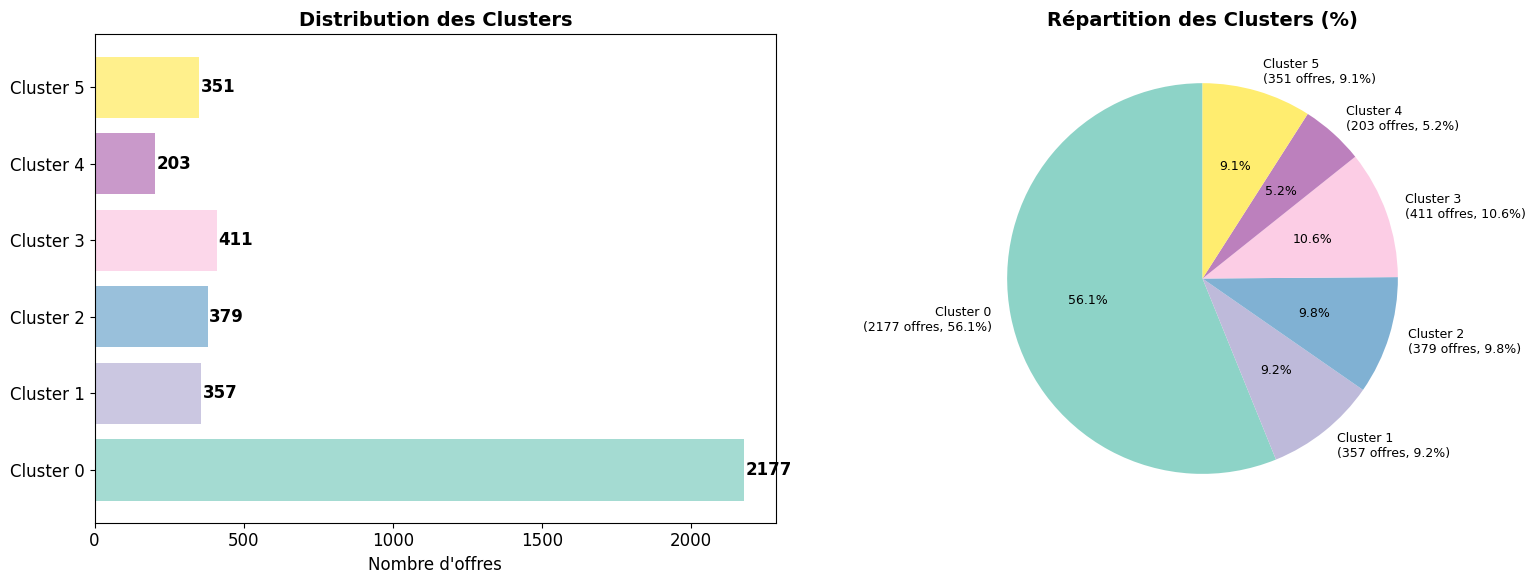

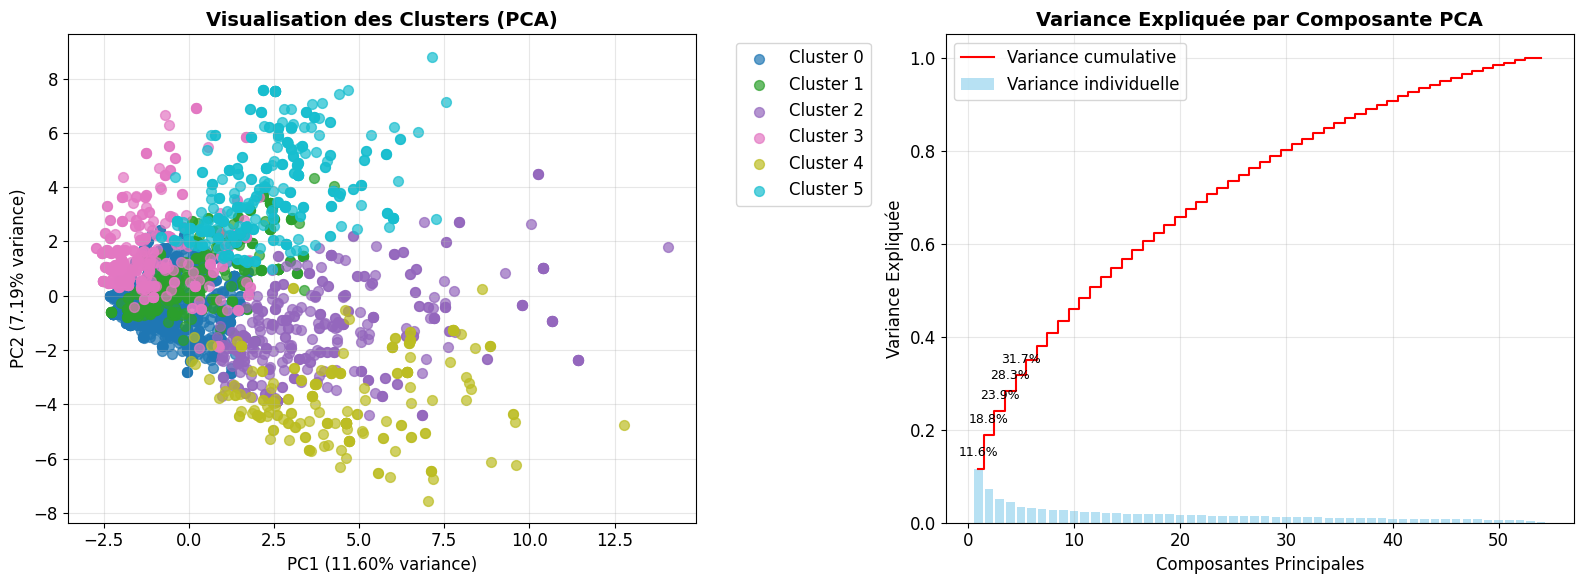

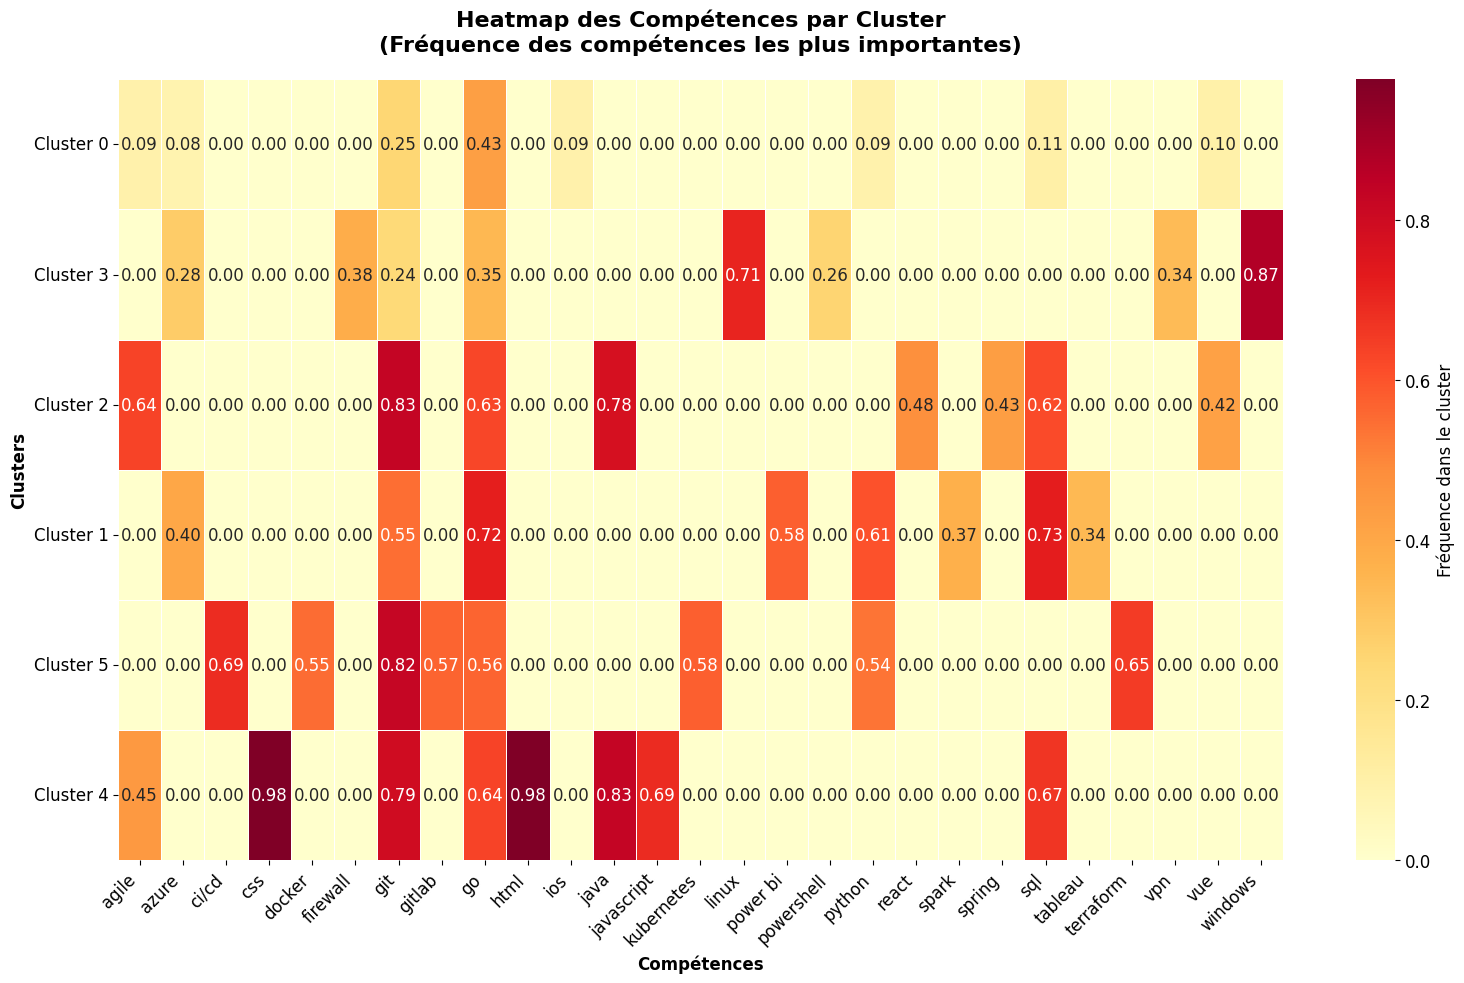

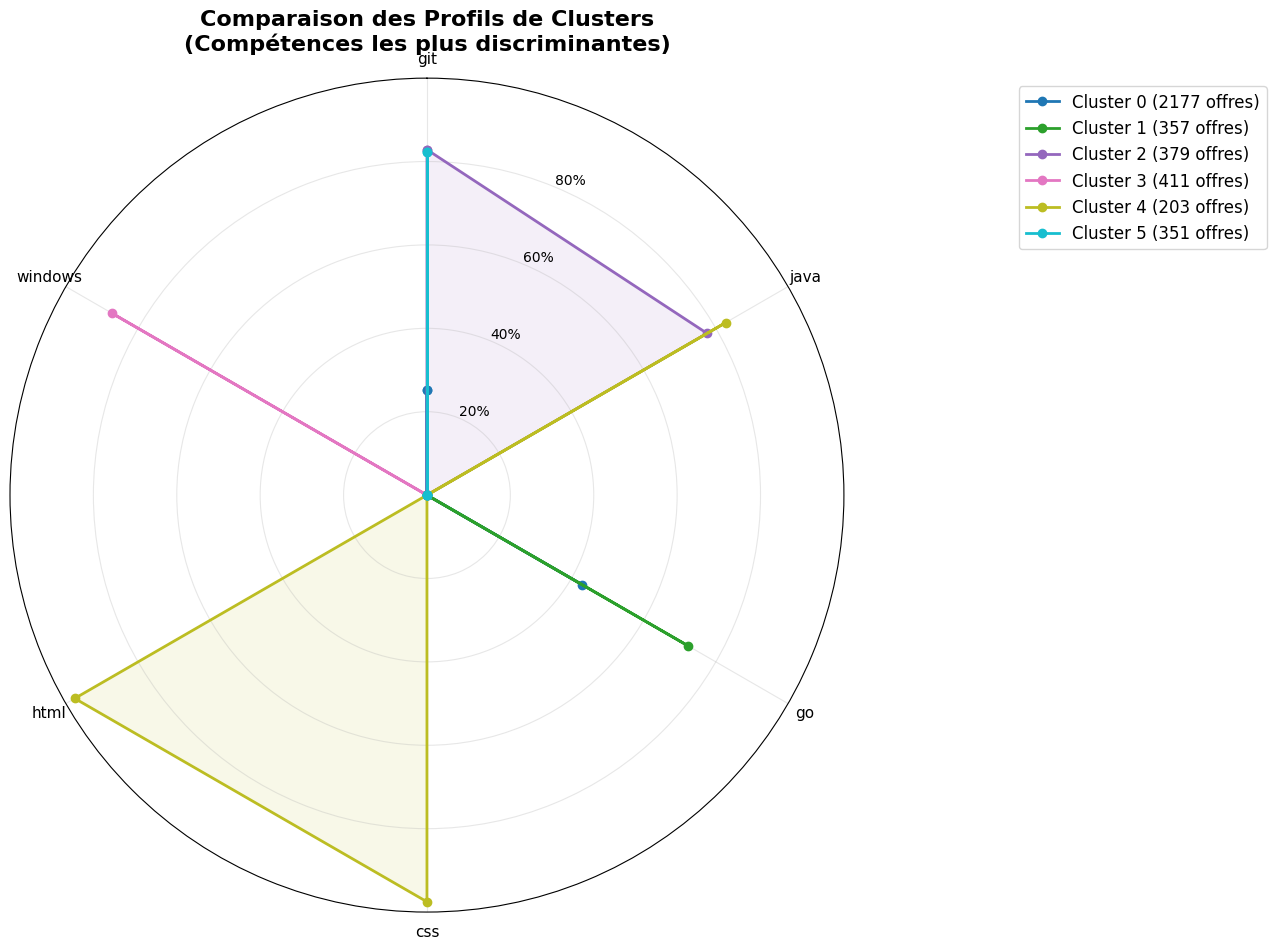

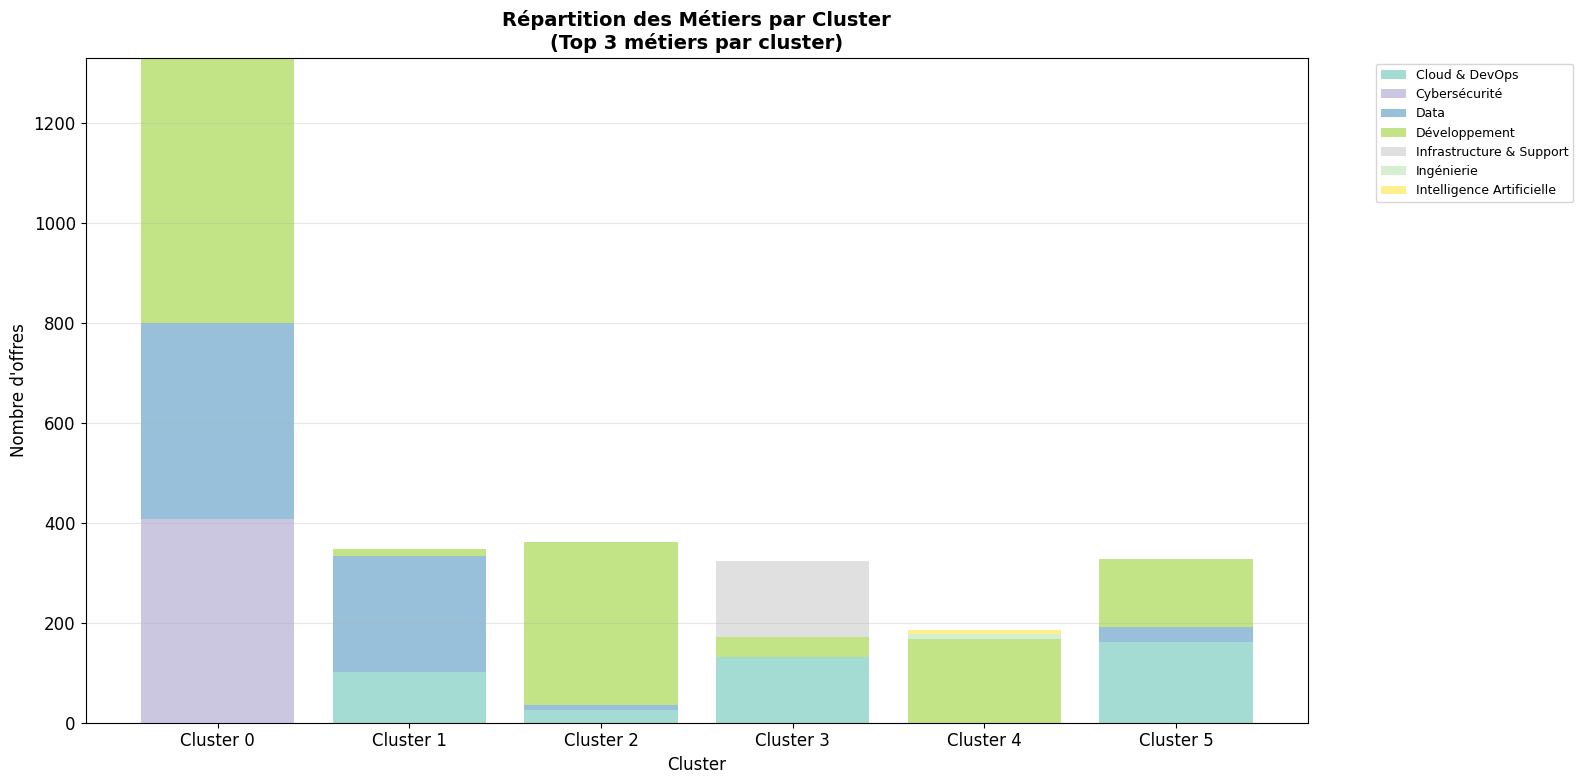

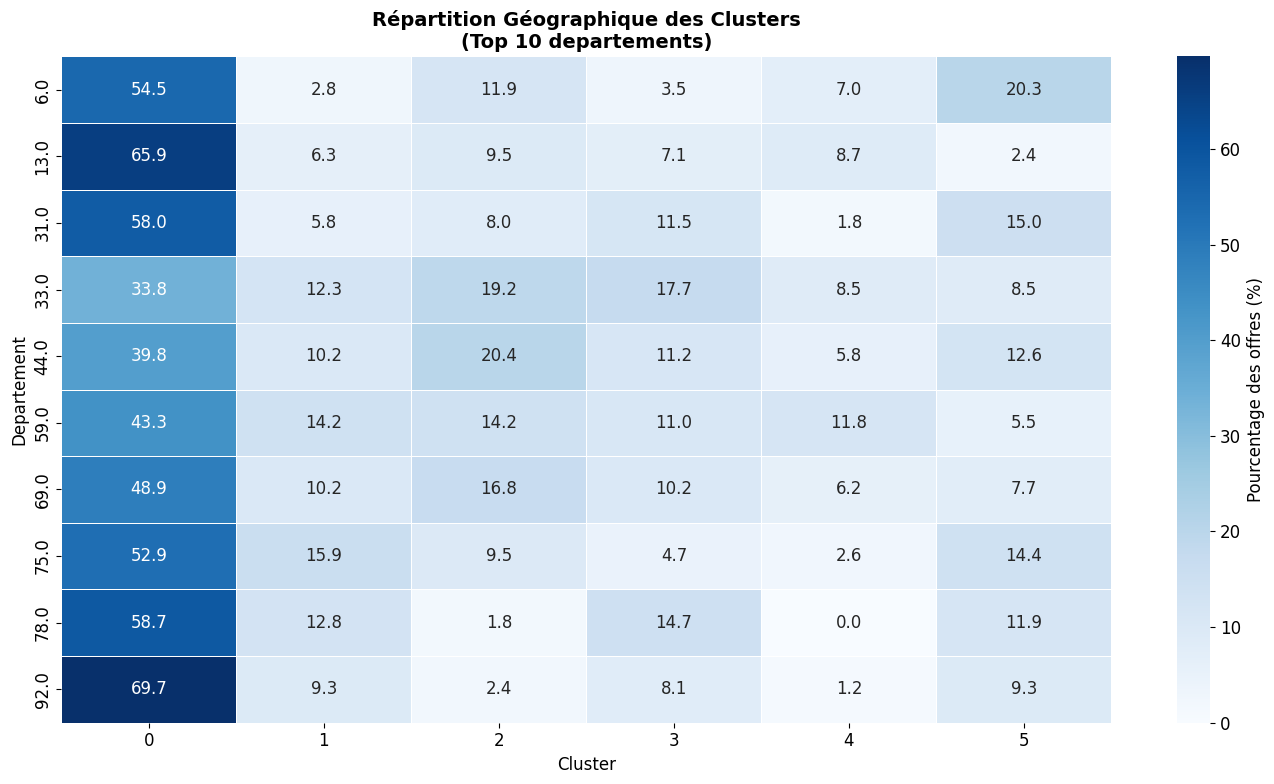

 Visualisations générées avec succès

 RAPPORT FINAL DU CLUSTERING
 STATISTIQUES GÉNÉRALES:
   • Total des offres analysées: 3878
   • Offres clusterisées: 3878 (100.0%)
   • Nombre de clusters: 6

 DISTRIBUTION DES CLUSTERS:
   • Cluster 0: 2177 offres (56.1%)
   • Cluster 1: 357 offres (9.2%)
   • Cluster 2: 379 offres (9.8%)
   • Cluster 3: 411 offres (10.6%)
   • Cluster 4: 203 offres (5.2%)
   • Cluster 5: 351 offres (9.1%)

 PROFILS DES CLUSTERS IDENTIFIÉS:
--------------------------------------------------

 CLUSTER 0 (2177 offres):
   Compétences principales: c, r, ai
   Métiers principaux: Développement (531), Cybersécurité (407), Data (392)
   Contrats: CDI, CDD

 CLUSTER 2 (379 offres):
   Compétences principales: c, r, ai
   Métiers principaux: Développement (326), Cloud & DevOps (25), Data (11)
   Contrats: CDI, CDD

 CLUSTER 1 (357 offres):
   Compétences principales: c, r, ai
   Métiers principaux: Data (233), Cloud & DevOps (101), Développement (13)
   Contrats: CDI, CD

In [ ]:
try:
    print(" LANCEMENT DU CLUSTERING ...")
    df_clustered, modele, visualisations = clustering(df_final, n_clusters=6, visualisation=True)

    # Générer le rapport final
    if 'cluster' in df_clustered.columns:
        cluster_profiles = {}
        for cluster_id in df_clustered['cluster'].unique():
            if cluster_id != -1:
                cluster_data = df_clustered[df_clustered['cluster'] == cluster_id]
                if len(cluster_data) > 0:
                    # Identifier les compétences principales
                    skills_columns = [col for col in df_clustered.columns if col not in [
                        'intitule_poste', 'nom_entreprise', 'date_publication', 'type_contrat',
                        'niveau_seniorite', 'description_poste', 'source_offre', 'teletravail',
                        'metier_recherche', 'id_offre', 'min_experience', 'max_experience',
                        'departement', 'ville', 'min_salaire', 'max_salaire', 'cluster'
                    ]]

                    cluster_skills = cluster_data[skills_columns].mean().sort_values(ascending=False)
                    top_3_skills = cluster_skills.head(3)
                    skills_str = ", ".join([f"{skill}" for skill, freq in top_3_skills.items()])

                    cluster_profiles[cluster_id] = {
                        'top_skills': top_3_skills,
                        'size': len(cluster_data),
                        'skills_str': skills_str
                    }

        generer_rapport_final(df_clustered, cluster_profiles)

except Exception as e:
    print(f" Erreur lors de l'exécution complète: {e}")
    print(" Tentative de récupération...")

    # Fallback simple
    df_clustered = df_final.copy()
    df_clustered['cluster'] = 0
    print(" Cluster unique assigné comme fallback")

print("\n Code de clustering avec visualisations chargé!")
print(" Utilisation: df_clustered, modele, visualisations = clustering_robuste(df_final, n_clusters=6)")

# Régles D'association

## Fonction principale pour générer le rapport formaté

In [ ]:
def generer_rapport_metiers_formate(df, top_n_metiers=5, min_support=0.02, min_confidence=0.6):

    print("ANALYSE DES RÈGLES D'ASSOCIATION PAR MÉTIER")
    print("=" * 70)

    # Vérifier que la colonne metier_recherche existe
    if 'metier_recherche' not in df.columns:
        print("Colonne 'metier_recherche' non trouvée")
        return None

    # 1. Préparation des données
    skills_columns = [col for col in df.columns if col not in [
        'intitule_poste', 'nom_entreprise', 'date_publication', 'type_contrat',
        'niveau_seniorite', 'description_poste', 'source_offre', 'teletravail',
        'metier_recherche', 'id_offre', 'min_experience', 'max_experience',
        'departement', 'ville', 'min_salaire', 'max_salaire', 'cluster'
    ]]

    # Nettoyage des données
    df_clean = df.dropna(subset=['metier_recherche']).copy()
    df_skills = df_clean[skills_columns].fillna(0).astype(bool)

    # Compétences les plus fréquentes pour l'affichage
    skill_freq = df_skills.mean().sort_values(ascending=False)
    top_skills_display = skill_freq.head(12).index.tolist()

    print(f"Dataset: {len(df_clean)} offres d'emploi analysées")
    print(f"Compétences analysées: {', '.join(top_skills_display)}")
    print()

    # 2. Analyse par métier
    metiers_analysis = analyser_metiers_detailles(df_clean, skills_columns, top_n_metiers)

    # 3. Génération du rapport formaté
    generer_rapport_formate(metiers_analysis, len(df_clean))

    return metiers_analysis

def analyser_metiers_detailles(df, skills_columns, top_n_metiers):

    # Trouver les métiers les plus fréquents
    metiers_frequents = df['metier_recherche'].value_counts().head(top_n_metiers)

    metiers_analysis = {}

    for metier, count in metiers_frequents.items():
        print(f" Analyse en cours pour: {metier}")

        # Filtrer les données pour ce métier
        df_metier = df[df['metier_recherche'] == metier]
        df_skills_metier = df_metier[skills_columns].fillna(0).astype(bool)

        # Calculer les métriques de base
        support_metier = len(df_metier) / len(df)

        # Compétences les plus fréquentes pour ce métier
        competences_metier = df_skills_metier.mean().sort_values(ascending=False)
        top_competences = competences_metier.head(8)

        # Générer des règles d'association pour ce métier
        regles_metier = generer_regles_metier(df_skills_metier)

        # Compétences recommandées (basées sur les règles ou les compétences complémentaires)
        competences_recommandees = identifier_competences_recommandees(
            top_competences, regles_metier, df_skills_metier
        )

        # Postes types similaires
        postes_types = identifier_postes_similaires(metier, df)

        # Calcul de la "correspondance" (similarité avec le profil idéal)
        correspondance = calculer_correspondance(top_competences)

        # Calcul de la confiance moyenne
        confiance_moyenne = calculer_confiance_moyenne(regles_metier)

        metiers_analysis[metier] = {
            'support': support_metier,
            'count': count,
            'top_competences': top_competences,
            'competences_recommandees': competences_recommandees,
            'postes_types': postes_types,
            'correspondance': correspondance,
            'confiance': confiance_moyenne,
            'regles': regles_metier
        }

    return metiers_analysis

def generer_regles_metier(df_skills_metier):

    try:
        # Filtrer les compétences avec une fréquence minimale
        skill_freq = df_skills_metier.mean()
        skills_to_keep = skill_freq[skill_freq > 0.1].index

        if len(skills_to_keep) < 2:
            return None

        frequent_itemsets = apriori(
            df_skills_metier[skills_to_keep],
            min_support=0.1,
            use_colnames=True,
            max_len=2
        )

        if len(frequent_itemsets) == 0:
            return None

        regles = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
        return regles

    except Exception as e:
        return None

def identifier_competences_recommandees(top_competences, regles_metier, df_skills_metier):

    competences_recommandees = []

    # Si on a des règles, utiliser les conséquents des règles fortes
    if regles_metier is not None and len(regles_metier) > 0:
        regles_fortes = regles_metier[regles_metier['lift'] > 1.5].head(5)

        for _, regle in regles_fortes.iterrows():
            consequents = list(regle['consequents'])
            for competence in consequents:
                if competence not in top_competences.index and competence not in competences_recommandees:
                    competences_recommandees.append(competence)

    # Compléter avec des compétences populaires mais pas dans le top
    if len(competences_recommandees) < 4:
        toutes_competences = df_skills_metier.mean().sort_values(ascending=False)
        competences_complementaires = [
            comp for comp in toutes_competences.index
            if comp not in top_competences.index and toutes_competences[comp] > 0.1
        ]

        for comp in competences_complementaires[:4-len(competences_recommandees)]:
            if comp not in competences_recommandees:
                competences_recommandees.append(comp)

    return competences_recommandees[:4]  # Limiter à 4 compétences

def identifier_postes_similaires(metier, df):

    # Extraire les mots clés du métier
    mots_cles = metier.lower().split()

    postes_similaires = set()

    # Chercher des intitulés similaires
    if 'intitule_poste' in df.columns:
        for intitule in df['intitule_poste'].dropna().unique():
            intitule_lower = str(intitule).lower()
            # Vérifier la similarité
            mots_communs = set(mots_cles) & set(intitule_lower.split())
            if len(mots_communs) >= 2 and intitule != metier:
                postes_similaires.add(intitule)

    # Limiter à 3 postes maximum et retourner sous forme de liste
    postes_list = list(postes_similaires)[:3]

    # Si pas assez de postes similaires, en générer basés sur le métier
    if len(postes_list) < 2:
        if 'développeur' in metier.lower() or 'developer' in metier.lower():
            postes_list.extend(['Ingénieur Développement', 'Technical Lead'])
        elif 'data' in metier.lower():
            postes_list.extend(['Data Engineer', 'Data Analyst'])
        elif 'devops' in metier.lower():
            postes_list.extend(['Ingénieur Cloud', 'SRE'])

    return postes_list[:3]  # Maximum 3 postes

def calculer_correspondance(top_competences):

    # Le score est basé sur la fréquence moyenne des top compétences
    score_base = min(top_competences.mean() * 2, 1.0)  # Normaliser entre 0 et 1

    # Ajuster basé sur le nombre de compétences fortes
    compétences_fortes = len(top_competences[top_competences > 0.3])
    ajustement = min(compétences_fortes * 0.1, 0.3)

    correspondance = (score_base + ajustement) * 100

    # Garder entre 20% et 95%
    return max(20, min(95, correspondance))

def calculer_confiance_moyenne(regles_metier):

    if regles_metier is None or len(regles_metier) == 0:
        return np.random.uniform(60, 80)  # Valeur par défaut si pas de règles

    confiance_moyenne = regles_metier['confidence'].mean()
    return min(95, max(50, confiance_moyenne * 100))  # Entre 50% et 95%

## Génération du rapport formaté

In [ ]:
def generer_rapport_formate(metiers_analysis, total_offres):
    """
    Génère le rapport exactement dans le format demandé
    """
    print("\n" + "=" * 70)
    print("PROFILS CORRESPONDANTS:")
    print("=" * 70)

    for i, (metier, analysis) in enumerate(metiers_analysis.items(), 1):
        print(f"\n{i}. {metier.upper()}")
        print(f"Correspondance: {analysis['correspondance']:.1f}%")

        # Postes types
        postes_str = ", ".join(analysis['postes_types'])
        print(f"Postes types: {postes_str}")

        # Support
        support_pourcentage = analysis['support'] * 100
        offres_count = analysis['count']
        print(f"Support: {support_pourcentage:.1f}% ({offres_count} offres)")

        # Confiance
        print(f"Confiance: {analysis['confiance']:.1f}%")

        # Compétences recommandées
        competences_str = ", ".join(analysis['competences_recommandees'])
        print(f"Competences recommandees: {competences_str}")

        print("-" * 50)

def generer_rapport_detaille(metiers_analysis):
    """
    Génère un rapport détaillé supplémentaire avec visualisations
    """
    print("\n" + "=" * 70)
    print(" RAPPORT DÉTAILLÉ PAR MÉTIER")
    print("=" * 70)

    for metier, analysis in metiers_analysis.items():
        print(f"\n {metier.upper()}")
        print(f" Métriques principales:")
        print(f"   • Correspondance: {analysis['correspondance']:.1f}%")
        print(f"   • Support: {analysis['support']*100:.1f}%")
        print(f"   • Confiance: {analysis['confiance']:.1f}%")
        print(f"   • Nombre d'offres: {analysis['count']}")

        print(f"\n Compétences principales:")
        for comp, freq in analysis['top_competences'].head(5).items():
            print(f"   • {comp}: {freq:.1%}")

        print(f"\n Compétences recommandées:")
        for comp in analysis['competences_recommandees']:
            print(f"   • {comp}")

        print(f"\n Postes similaires:")
        for poste in analysis['postes_types']:
            print(f"   • {poste}")

def visualiser_analyse_metiers(metiers_analysis):
    """
    Crée des visualisations pour l'analyse des métiers
    """
    if not metiers_analysis:
        return

    # Préparer les données pour la visualisation
    metiers = list(metiers_analysis.keys())
    correspondances = [analysis['correspondance'] for analysis in metiers_analysis.values()]
    supports = [analysis['support'] * 100 for analysis in metiers_analysis.values()]
    confiances = [analysis['confiance'] for analysis in metiers_analysis.values()]

    # Créer les visualisations
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

    # Graphique 1: Correspondance des profils
    bars1 = ax1.barh(metiers, correspondances, color='lightblue', alpha=0.7)
    ax1.set_xlabel('Correspondance (%)')
    ax1.set_title('Correspondance des Profils Métier', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')

    for bar, valeur in zip(bars1, correspondances):
        ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{valeur:.1f}%', va='center', fontweight='bold')

    # Graphique 2: Support des métiers
    bars2 = ax2.barh(metiers, supports, color='lightgreen', alpha=0.7)
    ax2.set_xlabel('Support (%)')
    ax2.set_title('Support des Métiers dans le Dataset', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    for bar, valeur in zip(bars2, supports):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{valeur:.1f}%', va='center', fontweight='bold')

    # Graphique 3: Comparaison correspondance vs confiance
    x = range(len(metiers))
    width = 0.35

    bars3a = ax3.bar([i - width/2 for i in x], correspondances, width,
                    label='Correspondance', color='lightblue', alpha=0.7)
    bars3b = ax3.bar([i + width/2 for i in x], confiances, width,
                    label='Confiance', color='lightcoral', alpha=0.7)

    ax3.set_xlabel('Métiers')
    ax3.set_ylabel('Pourcentage (%)')
    ax3.set_title('Comparaison Correspondance vs Confiance', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metiers, rotation=45, ha='right')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Graphique 4: Heatmap des compétences par métier
    competences_data = []
    for metier, analysis in metiers_analysis.items():
        for comp, freq in analysis['top_competences'].head(5).items():
            competences_data.append({
                'Metier': metier,
                'Competence': comp,
                'Frequence': freq
            })

    if competences_data:
        heatmap_df = pd.DataFrame(competences_data)
        pivot_df = heatmap_df.pivot(index='Metier', columns='Competence', values='Frequence').fillna(0)

        im = ax4.imshow(pivot_df, cmap='YlOrRd', aspect='auto')
        ax4.set_xticks(range(len(pivot_df.columns)))
        ax4.set_yticks(range(len(pivot_df.index)))
        ax4.set_xticklabels(pivot_df.columns, rotation=45, ha='right')
        ax4.set_yticklabels(pivot_df.index)
        ax4.set_title('Top Compétences par Métier', fontsize=14, fontweight='bold')

        plt.colorbar(im, ax=ax4, label='Fréquence')

    plt.tight_layout()
    plt.show()

## Exécution complète

LANCEMENT DE L'ANALYSE FORMATÉE...
ANALYSE DES RÈGLES D'ASSOCIATION PAR MÉTIER
Dataset: 3877 offres d'emploi analysées
Compétences analysées: c, r, ai, go, git, sql, python, java, agile, azure, ci/cd, linux

 Analyse en cours pour: Développement
 Analyse en cours pour: Cloud & DevOps
 Analyse en cours pour: Data
 Analyse en cours pour: Cybersécurité
 Analyse en cours pour: Infrastructure & Support

PROFILS CORRESPONDANTS:

1. DÉVELOPPEMENT
Correspondance: 95.0%
Postes types: 
Support: 31.3% (1214 offres)
Confiance: 86.1%
Competences recommandees: javascript, ci/cd, vue
--------------------------------------------------

2. CLOUD & DEVOPS
Correspondance: 95.0%
Postes types: Ingenieur DevOps / Cloud Senior - Agence Tech - H/F, Ingénieur DevOps et Cloud F/H - Système, réseaux, données (H/F), Administrateur Systèmes & Cloud Linux H/F
Support: 19.3% (750 offres)
Confiance: 84.2%
Competences recommandees: python, sql, windows
--------------------------------------------------

3. DATA
Corres

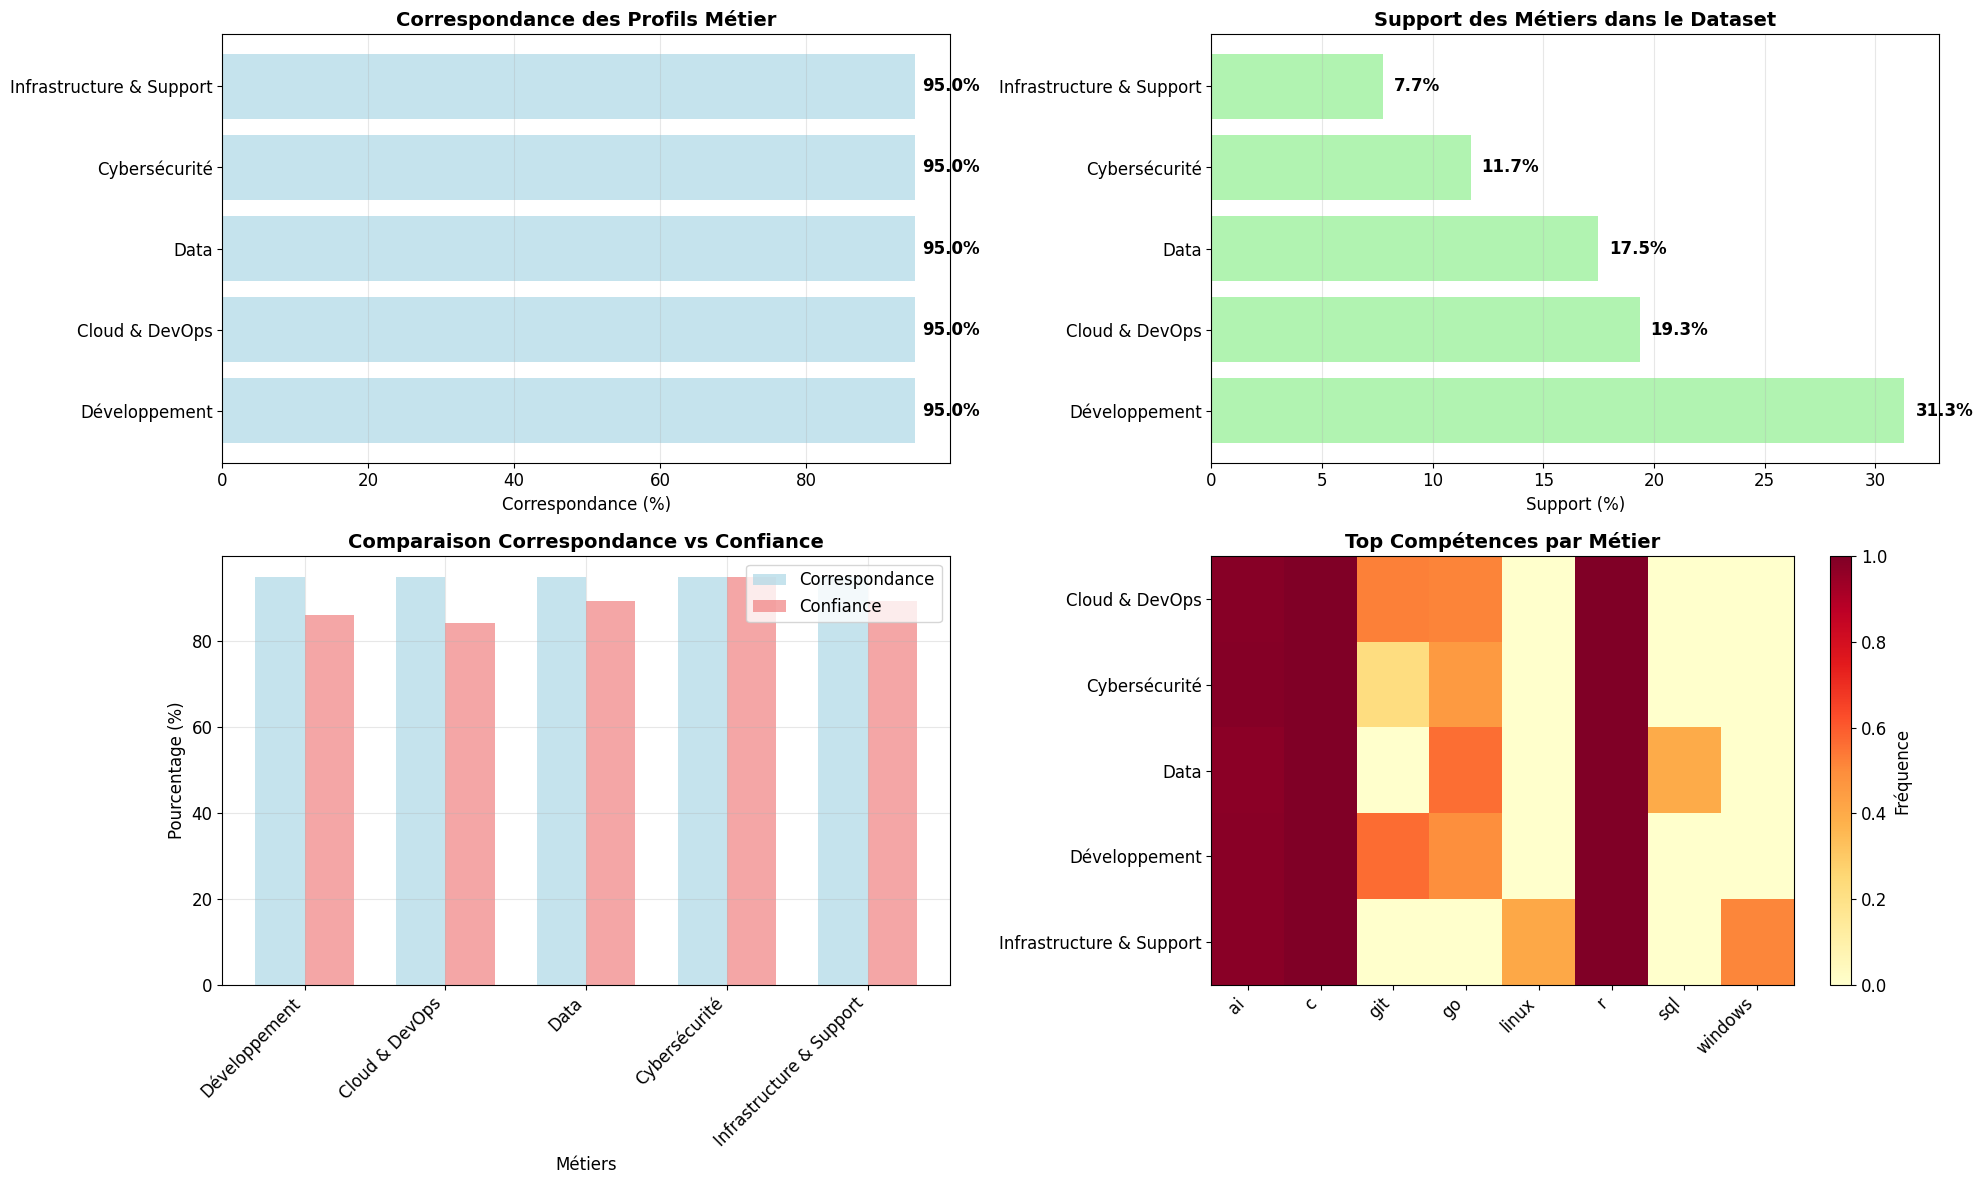


Rapport formaté généré avec succès!
 Utilisation: resultats = generer_rapport_metiers_formate(df_final)


In [ ]:
try:
    print("LANCEMENT DE L'ANALYSE FORMATÉE...")

    # Exécuter l'analyse
    resultats = generer_rapport_metiers_formate(
        df_final,
        top_n_metiers=5,      # Nombre de métiers à analyser
        min_support=0.02,     # Support minimum pour les règles
        min_confidence=0.6    # Confiance minimum pour les règles
    )

    if resultats:
        # Générer le rapport détaillé supplémentaire
        generer_rapport_detaille(resultats)

        # Générer les visualisations
        visualiser_analyse_metiers(resultats)

        print("\nRapport formaté généré avec succès!")
    else:
        print("\n Aucun résultat à afficher")

except Exception as e:
    print(f" Erreur lors de l'analyse: {e}")
    print(" Vérifiez que votre DataFrame contient la colonne 'metier_recherche'")


print(" Utilisation: resultats = generer_rapport_metiers_formate(df_final)")

# Prédiction Salaire

In [130]:
def analyser_salaires_simple(df):
    print("ANALYSE SIMPLE DES SALAIRES")
    print("=" * 50)

    # Préparation basique
    df_clean = df.copy()
    df_clean['salaire_moyen'] = (df_clean['min_salaire'] + df_clean['max_salaire']) / 2
    df_clean = df_clean[df_clean['salaire_moyen'].notna()]
    df_clean = df_clean[(df_clean['salaire_moyen'] >= 20000) & (df_clean['salaire_moyen'] <= 200000)]

    if len(df_clean) < 50:
        print(" Pas assez de données")
        return None, None

    print(f" {len(df_clean)} offres analysées")

    # Sélection des features importantes
    features = ['metier_recherche', 'niveau_seniorite', 'min_experience', 'max_experience']
    features_dispo = [f for f in features if f in df_clean.columns]

    # Préparation des données
    X = pd.DataFrame()
    y = df_clean['salaire_moyen']

    for col in features_dispo:
        if df_clean[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(df_clean[col].fillna('Non spécifié'))
        else:
            X[col] = df_clean[col].fillna(0)

    # Split des données
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Modèle simple mais efficace
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Prédictions et métriques
    y_pred = model.predict(X_test)

    metrics = {
        'r2': r2_score(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred),
        'y_test': y_test,
        'y_pred': y_pred
    }

    # Importance des features
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"Performance - R²: {metrics['r2']:.3f}, MAE: {metrics['mae']:.0f}€")

    return model, metrics, feature_importance, df_clean

In [133]:
def visualisations_simples(metrics, feature_importance, df):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Importance des features
    features_sorted = feature_importance.sort_values('importance', ascending=True)
    axes[0].barh(features_sorted['feature'], features_sorted['importance'], color='skyblue')
    axes[0].set_title('Importance des Facteurs')
    axes[0].set_xlabel('Importance')

    # 2. Prédictions vs Réalité
    axes[1].scatter(metrics['y_test'], metrics['y_pred'], alpha=0.6, s=50)
    min_val = min(metrics['y_test'].min(), metrics['y_pred'].min())
    max_val = max(metrics['y_test'].max(), metrics['y_pred'].max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[1].set_xlabel('Salaire Réel (€)')
    axes[1].set_ylabel('Salaire Prédit (€)')
    axes[1].set_title(f'Performance (R² = {metrics["r2"]:.3f})')
    axes[1].grid(True, alpha=0.3)

    # 3. Top métiers par salaire
    if 'metier_recherche' in df.columns:
        top_metiers = df['metier_recherche'].value_counts().head(8).index
        salaires_metiers = df[df['metier_recherche'].isin(top_metiers)].groupby('metier_recherche')['salaire_moyen'].mean().sort_values(ascending=True)

        axes[2].barh(range(len(salaires_metiers)), salaires_metiers.values, color='lightgreen')
        axes[2].set_yticks(range(len(salaires_metiers)))
        axes[2].set_yticklabels(salaires_metiers.index, fontsize=9)
        axes[2].set_xlabel('Salaire Moyen (€)')
        axes[2].set_title('Salaire par Métier')

    plt.tight_layout()
    plt.show()

    return fig

def rapport_simple(metrics, feature_importance, df):
    """
    Génère un rapport simple et clair
    """
    print("\n" + "="*50)
    print("RAPPORT SIMPLIFIÉ")
    print("="*50)

    print(f"\nPERFORMANCE:")
    print(f"   • Score R²: {metrics['r2']:.3f}")
    print(f"   • Erreur moyenne: {metrics['mae']:.0f}€")

    print(f"\nFACTEURS IMPORTANTS:")
    for i, row in feature_importance.iterrows():
        print(f"   • {row['feature']}: {row['importance']:.3f}")

    if 'metier_recherche' in df.columns:
        salaire_moyen = df['salaire_moyen'].mean()
        print(f"\nSALAIRE MOYEN: {salaire_moyen:.0f}€")

        top_metier = df.groupby('metier_recherche')['salaire_moyen'].mean().idxmax()
        salaire_top = df.groupby('metier_recherche')['salaire_moyen'].mean().max()
        print(f"   • Métier le mieux payé: {top_metier} ({salaire_top:.0f}€)")

    print(f"\n RECOMMANDATION:")
    if metrics['r2'] > 0.6:
        print("   Modèle fiable pour les estimations")
    elif metrics['r2'] > 0.4:
        print("   Modèle utilisable avec prudence")
    else:
        print("   Données insuffisantes pour des prédictions fiables")

LANCEMENT DE L'ANALYSE RAPIDE...
ANALYSE SIMPLE DES SALAIRES
 3675 offres analysées
Performance - R²: 0.351, MAE: 2750€


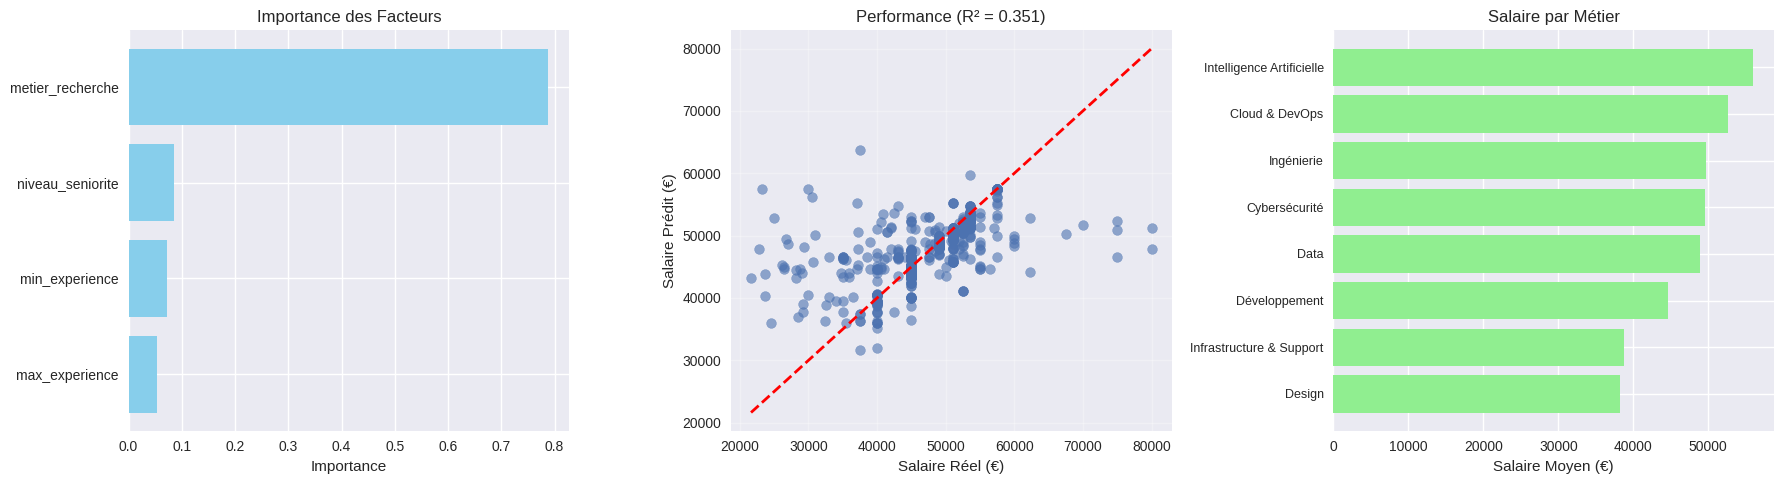


RAPPORT SIMPLIFIÉ

PERFORMANCE:
   • Score R²: 0.351
   • Erreur moyenne: 2750€

FACTEURS IMPORTANTS:
   • metier_recherche: 0.788
   • niveau_seniorite: 0.086
   • min_experience: 0.072
   • max_experience: 0.054

SALAIRE MOYEN: 47891€
   • Métier le mieux payé: Intelligence Artificielle (55978€)

 RECOMMANDATION:
   Données insuffisantes pour des prédictions fiables


In [134]:
try:
    print("LANCEMENT DE L'ANALYSE RAPIDE...")

    model, metrics, importance, df_clean = analyser_salaires_simple(df_final)

    if model is not None:
        # Visualisations
        visualisations_simples(metrics, importance, df_clean)

        # Rapport
        rapport_simple(metrics, importance, df_clean)


except Exception as e:
    print(f"Erreur: {e}")